# SECTION 3 - MongoDB Atlas (NoSQL Design and Implementation)
## Data Insertion, CRUD Operations, and Analytics

In [ ]:
# Install pymongo
!pip install pymongo --quiet
from pymongo import MongoClient, ASCENDING, DESCENDING
from pymongo.errors import DuplicateKeyError
from datetime import datetime
import json, pprint

# Connect to MongoDB Atlas
# Replace the URI with your Atlas connection string
MONGO_URI = "mongodb+srv://diaryofannet_db_user:<db_password>@cluster0.iobl3of.mongodb.net/?appName=Cluster0"
client = MongoClient(MONGO_URI)
db = client["northstar_db"]
print("Connected to MongoDB Atlas. Database:", db.name)

Connected to MongoDB Atlas. Database: northstar_db


In [ ]:
import pandas as pd

dfs = {
    'customers': pd.read_csv('/content/customers_clean.csv'),
    'deliveries': pd.read_csv('/content/deliveries_clean.csv'),
    'complaints': pd.read_csv('/content/complaints_clean.csv'),
    'drivers': pd.read_csv('/content/drivers_clean.csv'),
    'vehicles': pd.read_csv('/content/vehicles_clean.csv'),
    'hubs': pd.read_csv('/content/hubs_clean.csv'),
    'incidents': pd.read_csv('/content/incidents_clean.csv'),
    'orders': pd.read_csv('/content/orders_clean.csv'),
    'app_events': pd.read_csv('/content/app_events_clean.csv'),
}

print("DataFrames loaded into 'dfs' dictionary.")

DataFrames loaded into 'dfs' dictionary.


### 3.2 Collection Schema Definitions
#### NorthStar MongoDB Collections

In [ ]:
#SCHEMA: customers collection
customer_schema_example = {
    "_id": "C_EXAMPLE_001",
    "age": 26,
    "customer_type": "SME",                # Consumer | SME | Corporate
    "signup_date": datetime(2024, 11, 27),
    "loyalty_score": 44.9,
    "app_engagement_score": 69.2,
    "preferred_channel": "App",
    "account_status": "Active",
    "home_zone": "NORTH",
    "address": {
        "street": "14 Maple Avenue",
        "city": "Manchester",
        "postcode": "M1 1AA",
        "location": {
            "type": "Point",
            "coordinates": [-2.2426, 53.4808]   # [longitude, latitude]
        }
    },
    "active_orders": [
        {
            "order_id": "O00001",
            "service_type": "Parcel",
            "priority_level": "High",
            "status_history": [
                {"status": "Placed",     "timestamp": datetime(2026, 1, 15, 9, 0)},
                {"status": "Dispatched", "timestamp": datetime(2026, 1, 15, 10, 30)},
                {"status": "OnTime",     "timestamp": datetime(2026, 1, 15, 11, 45)}
            ]
        }
    ],
    "recent_app_events": [
        {"event_type": "eta_refresh", "timestamp": datetime(2026, 1, 15, 11, 0),
         "api_latency_ms": 210, "success": True}
    ]
}

# SCHEMA: deliveries collection=
delivery_schema_example = {
    "_id": "DL00001",
    "order_id": "O00938",
    "driver_id": "D004",            # referenced — not embedded
    "vehicle_id": "V056",           # referenced
    "hub_id": "H05",
    "dispatch_time": datetime(2024, 6, 18, 10, 57),
    "delivery_status": "Failed",
    "route_distance_km": 17.26,
    "fuel_or_charge_cost": 12.05,
    "manual_route_override_count": 1,
    "proof_of_completion_missing": False,
    "customer_rating_post_delivery": 3.07,
    "cost_per_km": round(12.05 / 17.26, 3),     # derived field
    "exceptions": [
        {
            "exception_type": "RouteOverride",
            "timestamp": datetime(2024, 6, 18, 11, 20),
            "description": "Driver overrode planned route due to road closure"
        }
    ],
    "route_waypoints": [
        {"lat": 53.48, "lng": -2.24, "timestamp": datetime(2024, 6, 18, 11, 0)},
        {"lat": 53.50, "lng": -2.22, "timestamp": datetime(2024, 6, 18, 11, 40)}
    ]
}

# SCHEMA: complaints collection
complaint_schema_example = {
    "_id": "CP0001",
    "customer_id": "C0464",
    "order_id": "O00814",
    "complaint_type": "AppIssue",
    "channel": "App",
    "severity": "High",
    "created_at": datetime(2025, 3, 30),
    "status": "Open",
    "resolution_days": 11,
    "compensation_amount": 23.99,
    "case_history": [
        {"event": "Complaint raised",   "by": "Customer",
         "timestamp": datetime(2025, 3, 30, 2, 36), "note": "App crashed during tracking"},
        {"event": "Assigned to agent",  "by": "System",
         "timestamp": datetime(2025, 3, 30, 9, 0),  "note": "Auto-routed to Digital Support"},
        {"event": "Escalated",          "by": "Agent",
         "timestamp": datetime(2025, 4, 2, 14, 0),  "note": "Customer requested manager callback"}
    ]
}

# SCHEMA: drivers collection
driver_schema_example = {
    "_id": "D004",
    "base_zone": "AIRPORT",
    "employment_type": "PartTime",
    "years_experience": 13,
    "training_score": 88.9,
    "driver_rating": 4.75,
    "shift_preference": "Morning",
    "active_flag": True,
    "performance_summary": {
        "total_deliveries": 47,
        "on_time_rate": 0.83,
        "avg_overrides_per_trip": 0.6,
        "last_updated": datetime(2026, 1, 1)
    }
}

# SCHEMA: incidents collection
incident_schema_example = {
    "_id": "I0001",
    "delivery_id": "DL00221",
    "incident_type": "BatteryAlert",
    "reported_at": datetime(2024, 3, 11, 23, 46),
    "severity": "Medium",
    "resolution_status": "Escalated",
    "resolved_hours": 12.3,
    "sensor_readings": [
        {"reading_type": "battery_pct", "value": 12.0,
         "timestamp": datetime(2024, 3, 11, 23, 40)}
    ]
}

print("Schema definitions ready. Sample schemas printed above.")
print("\ndelivery document keys:", list(delivery_schema_example.keys()))
print("complaint document keys:", list(complaint_schema_example.keys()))

Schema definitions ready. Sample schemas printed above.

delivery document keys: ['_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_status', 'route_distance_km', 'fuel_or_charge_cost', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'cost_per_km', 'exceptions', 'route_waypoints']
complaint document keys: ['_id', 'customer_id', 'order_id', 'complaint_type', 'channel', 'severity', 'created_at', 'status', 'resolution_days', 'compensation_amount', 'case_history']


### 3.3 Data Insertion

In [ ]:
# Insert sample documents into each collection
# Drop and recreate for clean demo
for col in ['customers','deliveries','complaints','drivers','vehicles',
            'hubs','incidents','orders','app_events']:
    db[col].drop()

# Insert customers
db.customers.insert_one(customer_schema_example)

# Batch insert additional customers from CSV
customers_py = dfs['customers'].copy()
customers_py.rename(columns={'customer_id':'_id'}, inplace=True)
customers_py['signup_date'] = pd.to_datetime(customers_py['signup_date'])
db.customers.insert_many(customers_py.to_dict('records'))

# Insert deliveries
deliveries_py = dfs['deliveries'].copy()
deliveries_py.rename(columns={'delivery_id':'_id'}, inplace=True)
db.deliveries.insert_many(deliveries_py.to_dict('records'))

# Insert complaints
complaints_py = dfs['complaints'].copy()
complaints_py.rename(columns={'complaint_id':'_id'}, inplace=True)
complaints_py['created_at'] = pd.to_datetime(complaints_py['created_at'])
# Attach a stub case_history to each complaint
complaints_py['case_history'] = complaints_py.apply(
    lambda r: [{"event": "Complaint raised", "channel": r['channel'],
                "timestamp": r['created_at'].isoformat(), "severity": r['severity']}],
    axis=1
)
db.complaints.insert_many(complaints_py.to_dict('records'))

# Insert drivers
drivers_py = dfs['drivers'].copy()
drivers_py.rename(columns={'driver_id':'_id'}, inplace=True)
db.drivers.insert_many(drivers_py.to_dict('records'))

# Insert vehicles
vehicles_py = dfs['vehicles'].copy()
vehicles_py.rename(columns={'vehicle_id':'_id'}, inplace=True)
db.vehicles.insert_many(vehicles_py.to_dict('records'))

# Insert hubs
hubs_py = dfs['hubs'].copy()
hubs_py.rename(columns={'hub_id':'_id'}, inplace=True)
db.hubs.insert_many(hubs_py.to_dict('records'))

# Insert incidents
incidents_py = dfs['incidents'].copy()
incidents_py.rename(columns={'incident_id':'_id'}, inplace=True)
db.incidents.insert_many(incidents_py.to_dict('records'))

# Insert orders
orders_py = dfs['orders'].copy()
orders_py.rename(columns={'order_id':'_id'}, inplace=True)
orders_py['order_created_at'] = pd.to_datetime(orders_py['order_created_at'])
db.orders.insert_many(orders_py.to_dict('records'))

# Insert app_events
events_py = dfs['app_events'].copy()
events_py.rename(columns={'event_id':'_id'}, inplace=True)
events_py['event_timestamp'] = pd.to_datetime(events_py['event_timestamp'])
db.app_events.insert_many(events_py.to_dict('records'))

print("Insertion complete. Collection counts:")
for col in ['customers','deliveries','complaints','drivers','vehicles',
            'hubs','incidents','orders','app_events']:
    print(f"  {col:15s}: {db[col].count_documents({}):5d} documents")

Insertion complete. Collection counts:
  customers      :   651 documents
  deliveries     :   950 documents
  complaints     :   320 documents
  drivers        :   170 documents
  vehicles       :   120 documents
  hubs           :     8 documents
  incidents      :   280 documents
  orders         :  1250 documents
  app_events     :   640 documents


\### 3.4 CRUD Operations

In [ ]:
# QUERY 1: Find all failed deliveries
q1 = list(db.deliveries.find({"delivery_status": "Failed"},{"_id":1,"order_id":1,
          "hub_id":1,"route_distance_km":1}).limit(5))
print("Q1 — Failed deliveries (first 5):")
for doc in q1: print(" ", doc)
print("Total failed:", db.deliveries.count_documents({"delivery_status":"Failed"}))

Q1 — Failed deliveries (first 5):
  {'_id': 'DL00001', 'order_id': 'O00938', 'hub_id': 'H05', 'route_distance_km': 17.26}
  {'_id': 'DL00010', 'order_id': 'O00836', 'hub_id': 'H08', 'route_distance_km': 9.85}
  {'_id': 'DL00012', 'order_id': 'O01207', 'hub_id': 'H05', 'route_distance_km': 16.96}
  {'_id': 'DL00022', 'order_id': 'O01027', 'hub_id': 'H07', 'route_distance_km': 15.81}
  {'_id': 'DL00026', 'order_id': 'O00906', 'hub_id': 'H04', 'route_distance_km': 14.27}
Total failed: 132


In [ ]:
# QUERY 2: Find deliveries with > 1 manual route override
q2 = list(db.deliveries.find(
    {"manual_route_override_count": {"$gt": 1}},
    {"_id":1, "driver_id":1, "manual_route_override_count":1, "delivery_status":1}
).sort("manual_route_override_count", DESCENDING).limit(8))
print("Q2 — Deliveries with >1 override (top 8 by override count):")
for doc in q2: print(" ", doc)

Q2 — Deliveries with >1 override (top 8 by override count):
  {'_id': 'DL00473', 'driver_id': 'D105', 'delivery_status': 'OnTime', 'manual_route_override_count': 7}
  {'_id': 'DL00744', 'driver_id': 'D052', 'delivery_status': 'Delayed', 'manual_route_override_count': 5}
  {'_id': 'DL00672', 'driver_id': 'D108', 'delivery_status': 'OnTime', 'manual_route_override_count': 5}
  {'_id': 'DL00922', 'driver_id': 'D112', 'delivery_status': 'Delayed', 'manual_route_override_count': 5}
  {'_id': 'DL00055', 'driver_id': 'D069', 'delivery_status': 'Delayed', 'manual_route_override_count': 5}
  {'_id': 'DL00881', 'driver_id': 'D127', 'delivery_status': 'Delayed', 'manual_route_override_count': 5}
  {'_id': 'DL00374', 'driver_id': 'D090', 'delivery_status': 'OnTime', 'manual_route_override_count': 5}
  {'_id': 'DL00085', 'driver_id': 'D127', 'delivery_status': 'OnTime', 'manual_route_override_count': 5}


In [ ]:
# QUERY 3: Aggregate: complaint count and avg compensation by type
q3 = list(db.complaints.aggregate([
    {"$group": {
        "_id": "$complaint_type",
        "count": {"$sum": 1},
        "avg_resolution_days":  {"$avg": "$resolution_days"},
        "avg_compensation":     {"$avg": "$compensation_amount"},
        "total_compensation":   {"$sum": "$compensation_amount"}
    }},
    {"$sort": {"count": -1}}
]))
print("Q3 — Complaint analytics by type:")
for doc in q3:
    print(f"  {doc['_id']:22s}: count={doc['count']:3d}",
          f"avg_res={doc['avg_resolution_days']:.1f}d",
          f"avg_comp=£{doc['avg_compensation']:.2f}",
          f"total_comp=£{doc['total_compensation']:.0f}")

Q3 — Complaint analytics by type:
  Delay                 : count=101 avg_res=7.3d avg_comp=£nan total_comp=£nan
  MissedPickup          : count= 64 avg_res=7.6d avg_comp=£nan total_comp=£nan
  AppIssue              : count= 53 avg_res=8.6d avg_comp=£nan total_comp=£nan
  DriverBehaviour       : count= 51 avg_res=8.2d avg_comp=£nan total_comp=£nan
  SupportExperience     : count= 20 avg_res=7.5d avg_comp=£17.12 total_comp=£342
  Billing               : count= 16 avg_res=7.8d avg_comp=£23.87 total_comp=£382
  Damage                : count= 15 avg_res=11.3d avg_comp=£23.98 total_comp=£360


In [ ]:
# QUERY 4: UPDATE - mark complaints older than 15 resolution days as Escalated
update_result = db.complaints.update_many(
    {"resolution_days": {"$gt": 15}, "status": "Open"},
    {"$set": {"status": "Escalated",
              "escalated_at": datetime.utcnow()}}
)
print(f"Q4 — Escalated {update_result.modified_count} long-running Open complaints")

/tmp/ipykernel_11701/3876243130.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "escalated_at": datetime.utcnow()}}


Q4 — Escalated 5 long-running Open complaints


In [ ]:
# QUERY 5: INSERT - new incident event
new_incident = {
    "_id": "I9999",
    "delivery_id": "DL00100",
    "incident_type": "GPSLoss",
    "reported_at": datetime.utcnow(),
    "severity": "High",
    "resolution_status": "Open",
    "resolved_hours": None,
    "sensor_readings": [{"reading_type": "gps_signal", "value": 0,
                          "timestamp": datetime.utcnow().isoformat()}]
}
try:
    db.incidents.insert_one(new_incident)
    print("Q5 — New incident I9999 inserted successfully")
except DuplicateKeyError:
    print("I9999 already exists")

Q5 — New incident I9999 inserted successfully


/tmp/ipykernel_11701/435762625.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "reported_at": datetime.utcnow(),
/tmp/ipykernel_11701/435762625.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()}]


In [ ]:
# QUERY 6: DELETE - remove dummy incident
del_result = db.incidents.delete_one({"_id": "I9999"})
print(f"Q6 — Deleted {del_result.deleted_count} dummy incident document")

Q6 — Deleted 1 dummy incident document


In [ ]:
# QUERY 7: Find vehicles with battery health < 70% (critical threshold)
q7 = list(db.vehicles.find(
    {"battery_health_pct": {"$lt": 70}, "maintenance_status": "Active"},
    {"_id":1, "vehicle_type":1, "assigned_zone":1,
     "battery_health_pct":1, "odometer_km":1}
).sort("battery_health_pct", ASCENDING).limit(8))
print("Q7 — Active vehicles with critically low battery (operational failure risk):")
for doc in q7: print(" ", doc)

Q7 — Active vehicles with critically low battery (operational failure risk):
  {'_id': 'V025', 'vehicle_type': 'Diesel', 'assigned_zone': 'Airport', 'battery_health_pct': 42.0, 'odometer_km': 52074}
  {'_id': 'V087', 'vehicle_type': 'Hybrid', 'assigned_zone': 'Airport', 'battery_health_pct': 49.7, 'odometer_km': 116811}
  {'_id': 'V049', 'vehicle_type': 'Diesel', 'assigned_zone': 'East', 'battery_health_pct': 55.9, 'odometer_km': 15278}
  {'_id': 'V012', 'vehicle_type': 'Hybrid', 'assigned_zone': 'South', 'battery_health_pct': 56.2, 'odometer_km': 52021}
  {'_id': 'V067', 'vehicle_type': 'Hybrid', 'assigned_zone': 'Central', 'battery_health_pct': 57.3, 'odometer_km': 176145}
  {'_id': 'V115', 'vehicle_type': 'Diesel', 'assigned_zone': 'South', 'battery_health_pct': 57.9, 'odometer_km': 85919}
  {'_id': 'V091', 'vehicle_type': 'Hybrid', 'assigned_zone': 'East', 'battery_health_pct': 58.5, 'odometer_km': 172956}
  {'_id': 'V005', 'vehicle_type': 'CargoVan', 'assigned_zone': 'West', 'batt

In [ ]:
# QUERY 8: Analyze delivery performance by hub
q8 = list(db.deliveries.aggregate([
    {"$group": {
        "_id": "$hub_id",
        "total":    {"$sum": 1},
        "failed":   {"$sum": {"$cond": [{"$eq":["$delivery_status","Failed"]}, 1, 0]}},
        "delayed":  {"$sum": {"$cond": [{"$eq":["$delivery_status","Delayed"]}, 1, 0]}},
        "avg_cost": {"$avg": "$fuel_or_charge_cost"},
        "total_overrides": {"$sum": "$manual_route_override_count"}
    }},
    {"$addFields": {"failure_rate": {"$divide": ["$failed", "$total"]}}},
    {"$sort": {"failure_rate": -1}}
]))
print("Q8 — Delivery performance by hub (MongoDB aggregation):")
for doc in q8:
    print(f"  Hub {doc['_id']}: total={doc['total']:3d}",
          f"failed={doc['failed']:2d} ({doc['failure_rate']*100:.1f}%)",
          f"delayed={doc['delayed']:2d}",
          f"avg_cost=£{doc['avg_cost']:.2f}",
          f"overrides={doc['total_overrides']}")

Q8 — Delivery performance by hub (MongoDB aggregation):
  Hub H08: total=128 failed=26 (20.3%) delayed=22 avg_cost=£11.71 overrides=142
  Hub H05: total=115 failed=23 (20.0%) delayed=25 avg_cost=£13.69 overrides=109
  Hub H06: total=104 failed=15 (14.4%) delayed=27 avg_cost=£13.32 overrides=95
  Hub H04: total=127 failed=16 (12.6%) delayed=28 avg_cost=£13.17 overrides=111
  Hub H01: total=136 failed=17 (12.5%) delayed=26 avg_cost=£12.76 overrides=140
  Hub H07: total=115 failed=14 (12.2%) delayed=25 avg_cost=£12.92 overrides=121
  Hub H02: total=106 failed=10 (9.4%) delayed=26 avg_cost=£12.57 overrides=97
  Hub H03: total=119 failed=11 (9.2%) delayed=23 avg_cost=£12.74 overrides=106


In [ ]:
# QUERY 9: Lookup join - deliveries with driver info
q9 = list(db.deliveries.aggregate([
    {"$match": {"delivery_status": "Failed"}},
    {"$lookup": {
        "from": "drivers",
        "localField": "driver_id",
        "foreignField": "_id",
        "as": "driver_info"
    }},
    {"$unwind": "$driver_info"},
    {"$project": {
        "_id": 1, "driver_id": 1, "delivery_status": 1,
        "driver_info.employment_type": 1,
        "driver_info.driver_rating": 1,
        "driver_info.training_score": 1
    }},
    {"$limit": 5}
]))
print("Q9 — Failed deliveries with driver context (lookup join):")
for doc in q9: print(" ", doc)

Q9 — Failed deliveries with driver context (lookup join):
  {'_id': 'DL00001', 'driver_id': 'D004', 'delivery_status': 'Failed', 'driver_info': {'employment_type': 'PartTime', 'training_score': 88.9, 'driver_rating': 4.75}}
  {'_id': 'DL00010', 'driver_id': 'D058', 'delivery_status': 'Failed', 'driver_info': {'employment_type': 'FullTime', 'training_score': 82.7, 'driver_rating': 4.27}}
  {'_id': 'DL00012', 'driver_id': 'D051', 'delivery_status': 'Failed', 'driver_info': {'employment_type': 'FullTime', 'training_score': 75.4, 'driver_rating': 3.58}}
  {'_id': 'DL00022', 'driver_id': 'D088', 'delivery_status': 'Failed', 'driver_info': {'employment_type': 'Contract', 'training_score': 84.3, 'driver_rating': 4.17}}
  {'_id': 'DL00026', 'driver_id': 'D092', 'delivery_status': 'Failed', 'driver_info': {'employment_type': 'FullTime', 'training_score': 88.2, 'driver_rating': 4.24}}


In [ ]:
# QUERY 10: Aggregate avg API latency by event type
q10 = list(db.app_events.aggregate([
    {"$group": {
        "_id": "$event_type",
        "avg_latency": {"$avg": "$api_latency_ms"},
        "fail_count":  {"$sum": {"$cond":[{"$eq":["$success_flag",0]}, 1, 0]}},
        "total":       {"$sum": 1}
    }},
    {"$sort": {"avg_latency": -1}}
]))
print("Q10 — App event performance by type:")
for doc in q10:
    print(f"  {doc['_id']:20s}: avg_latency={doc['avg_latency']:.0f}ms",
          f"failures={doc['fail_count']}/{doc['total']}")

Q10 — App event performance by type:
  delivery_instruction_update: avg_latency=496ms failures=0/75
  chat_opened         : avg_latency=478ms failures=0/88
  chat_escalated      : avg_latency=478ms failures=19/38
  payment_retry       : avg_latency=473ms failures=19/69
  track_order         : avg_latency=461ms failures=0/138
  search_route        : avg_latency=457ms failures=0/99
  eta_refresh         : avg_latency=452ms failures=0/105
  cancel_attempt      : avg_latency=417ms failures=0/28


In [ ]:
# QUERY 11: Find incidents not resolved within 24 hours
q11 = list(db.incidents.find(
    {"resolved_hours": {"$gt": 24}, "resolution_status": {"$ne": "Closed"}},
    {"_id":1, "incident_type":1, "severity":1,
     "resolved_hours":1, "resolution_status":1}
).sort("resolved_hours", DESCENDING))
print(f"Q11 — Incidents unresolved after 24h: {len(q11)}")
for doc in q11[:5]: print(" ", doc)

Q11 — Incidents unresolved after 24h: 9
  {'_id': 'I0199', 'incident_type': 'ProofMissing', 'severity': 'Medium', 'resolution_status': 'Open', 'resolved_hours': 33.8}
  {'_id': 'I0232', 'incident_type': 'TemperatureIssue', 'severity': 'Medium', 'resolution_status': 'PendingVendor', 'resolved_hours': 29.3}
  {'_id': 'I0080', 'incident_type': 'ProofMissing', 'severity': 'Critical', 'resolution_status': 'Open', 'resolved_hours': 27.8}
  {'_id': 'I0204', 'incident_type': 'AppSyncError', 'severity': 'Low', 'resolution_status': 'Open', 'resolved_hours': 27.4}
  {'_id': 'I0022', 'incident_type': 'BatteryAlert', 'severity': 'Medium', 'resolution_status': 'Escalated', 'resolved_hours': 26.8}


In [ ]:
# QUERY 12: UPDATE compensation for all Damage complaints to minimum £30
upd12 = db.complaints.update_many(
    {"complaint_type": "Damage", "compensation_amount": {"$lt": 30}},
    {"$set": {"compensation_amount": 30.0,
               "policy_adjusted": True}}
)
print(f"Q12 — Updated {upd12.modified_count} Damage complaints to minimum £30 compensation")

Q12 — Updated 9 Damage complaints to minimum £30 compensation


In [ ]:
#  QUERY 13: Retrieve nested case_history from escalated complaints
q13 = list(db.complaints.find(
    {"status": "Escalated"},
    {"_id":1, "complaint_type":1, "severity":1,
     "case_history":1, "resolution_days":1}
).limit(3))
print("Q13 — Escalated complaint case histories (nested document retrieval):")
for doc in q13: pprint.pprint(doc)

Q13 — Escalated complaint case histories (nested document retrieval):
{'_id': 'CP0003',
 'case_history': [{'channel': 'Chatbot',
                   'event': 'Complaint raised',
                   'severity': 'High',
                   'timestamp': '2024-01-02T15:47:00'}],
 'complaint_type': 'Delay',
 'resolution_days': 16,
 'severity': 'High'}
{'_id': 'CP0007',
 'case_history': [{'channel': 'App',
                   'event': 'Complaint raised',
                   'severity': 'Medium',
                   'timestamp': '2025-01-15T21:57:00'}],
 'complaint_type': 'MissedPickup',
 'resolution_days': 4,
 'severity': 'Medium'}
{'_id': 'CP0024',
 'case_history': [{'channel': 'Chatbot',
                   'event': 'Complaint raised',
                   'severity': 'Medium',
                   'timestamp': '2024-03-11T05:19:00'}],
 'complaint_type': 'AppIssue',
 'resolution_days': 9,
 'severity': 'Medium'}


In [ ]:
# QUERY 14: Driver performance - sort by combined risk (low rating + high overrides)
q14 = list(db.deliveries.aggregate([
    {"$group": {
        "_id": "$driver_id",
        "total": {"$sum": 1},
        "avg_rating": {"$avg": "$customer_rating_post_delivery"},
        "total_overrides": {"$sum": "$manual_route_override_count"},
        "failures":  {"$sum": {"$cond":[{"$eq":["$delivery_status","Failed"]},1,0]}}
    }},
    {"$match": {"total": {"$gte": 5}}},  # drivers with enough trips for reliable stats
    {"$sort": {"failures": -1, "avg_rating": 1}},
    {"$limit": 10}
]))
print("Q14 — Highest-risk drivers (most failures, lowest ratings):")
for doc in q14:
    print(f"  {doc['_id']}: trips={doc['total']:3d}",
          f"avg_rating={doc['avg_rating']:.2f}",
          f"overrides={doc['total_overrides']:3d}",
          f"failures={doc['failures']}")

Q14 — Highest-risk drivers (most failures, lowest ratings):
  D133: trips= 12 avg_rating=3.42 overrides= 11 failures=4
  D024: trips=  8 avg_rating=3.44 overrides=  9 failures=4
  D104: trips=  7 avg_rating=3.93 overrides= 12 failures=4
  D092: trips=  5 avg_rating=3.38 overrides=  2 failures=3
  D004: trips=  9 avg_rating=3.51 overrides=  7 failures=3
  D131: trips=  9 avg_rating=3.66 overrides= 15 failures=3
  D055: trips= 10 avg_rating=3.81 overrides= 11 failures=3
  D083: trips=  9 avg_rating=3.91 overrides=  9 failures=3
  D010: trips=  7 avg_rating=4.15 overrides=  6 failures=3
  D108: trips= 11 avg_rating=4.41 overrides= 15 failures=3


In [ ]:
# QUERY 15: Hub capacity vs actual delivery load
q15 = list(db.deliveries.aggregate([
    {"$group": {"_id": "$hub_id", "delivery_count": {"$sum": 1}}},
    {"$lookup": {
        "from": "hubs", "localField": "_id",
        "foreignField": "_id", "as": "hub_info"
    }},
    {"$unwind": "$hub_info"},
    {"$project": {
        "hub_name": "$hub_info.hub_name",
        "zone": "$hub_info.zone",
        "capacity_score": "$hub_info.capacity_score",
        "delivery_count": 1,
        "load_ratio": {"$divide": ["$delivery_count", "$hub_info.capacity_score"]}
    }},
    {"$sort": {"load_ratio": -1}}
]))
print("Q15 — Hub load ratio (deliveries per capacity unit):")
for doc in q15:
    print(f"  {doc['hub_name']:20s} zone={doc['zone']:10s}",
          f"capacity={doc['capacity_score']:3d}",
          f"deliveries={doc['delivery_count']:3d}",
          f"load_ratio={doc['load_ratio']:.2f}")

Q15 — Hub load ratio (deliveries per capacity unit):
  Midtown Relay        zone=Central    capacity= 63 deliveries=128 load_ratio=2.03
  West Gate            zone=West       capacity= 69 deliveries=127 load_ratio=1.84
  Riverside Hub        zone=Riverside  capacity= 66 deliveries=115 load_ratio=1.74
  North Exchange       zone=North      capacity= 82 deliveries=136 load_ratio=1.66
  East Dock            zone=East       capacity= 74 deliveries=119 load_ratio=1.61
  Airport Hub          zone=Airport    capacity= 71 deliveries=104 load_ratio=1.46
  South Link           zone=South      capacity= 78 deliveries=106 load_ratio=1.36
  Central Core         zone=Central    capacity= 88 deliveries=115 load_ratio=1.31


### 3.5 Visualisation from MongoDB Query Results

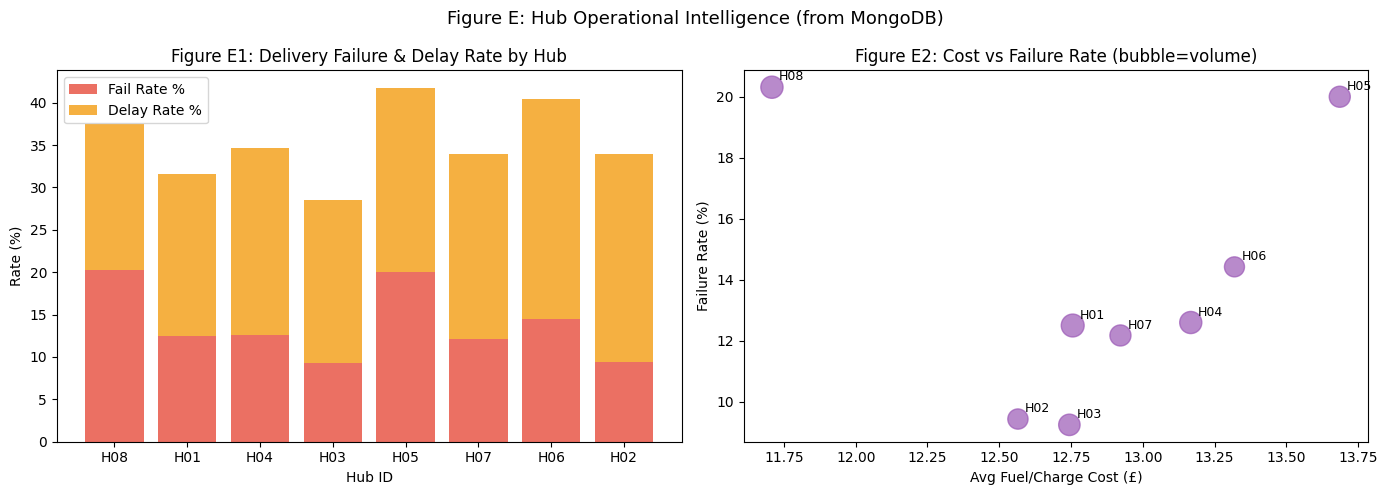


INTERPRETATION:
Hubs combining high failure rate AND high cost represent double jeopardy —
they are expensive to run and still deliver poor outcomes. These hubs need
immediate operational review: fleet type allocation, driver assignments,
and local route-planning algorithm calibration.



In [ ]:
import matplotlib.pyplot as plt

# Plot E: Hub failure rate from MongoDB aggregation
hub_perf = list(db.deliveries.aggregate([
    {"$group": {
        "_id": "$hub_id",
        "total":   {"$sum": 1},
        "failed":  {"$sum": {"$cond":[{"$eq":["$delivery_status","Failed"]},1,0]}},
        "delayed": {"$sum": {"$cond":[{"$eq":["$delivery_status","Delayed"]},1,0]}},
        "avg_cost":{"$avg": "$fuel_or_charge_cost"}
    }},
    {"$addFields": {
        "fail_rate":  {"$multiply":[{"$divide":["$failed","$total"]},100]},
        "delay_rate": {"$multiply":[{"$divide":["$delayed","$total"]},100]}
    }}
]))

hub_df = pd.DataFrame(hub_perf).rename(columns={'_id':'hub_id'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hub_df['hub_id'], hub_df['fail_rate'], color='#e74c3c', alpha=0.8, label='Fail Rate %')
axes[0].bar(hub_df['hub_id'], hub_df['delay_rate'], bottom=hub_df['fail_rate'],
            color='#f39c12', alpha=0.8, label='Delay Rate %')
axes[0].set_xlabel('Hub ID'); axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Figure E1: Delivery Failure & Delay Rate by Hub')
axes[0].legend()

axes[1].scatter(hub_df['avg_cost'], hub_df['fail_rate'],
                s=hub_df['total']*2, c='#9b59b6', alpha=0.7)
for _, row in hub_df.iterrows():
    axes[1].annotate(row['hub_id'], (row['avg_cost'], row['fail_rate']),
                     textcoords='offset points', xytext=(5,5), fontsize=9)
axes[1].set_xlabel('Avg Fuel/Charge Cost (£)')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_title('Figure E2: Cost vs Failure Rate (bubble=volume)')

fig.suptitle('Figure E: Hub Operational Intelligence (from MongoDB)', fontsize=13)
plt.tight_layout(); plt.show()

/tmp/ipykernel_11701/4253919662.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(trend_df['month'], rotation=45, ha='right')


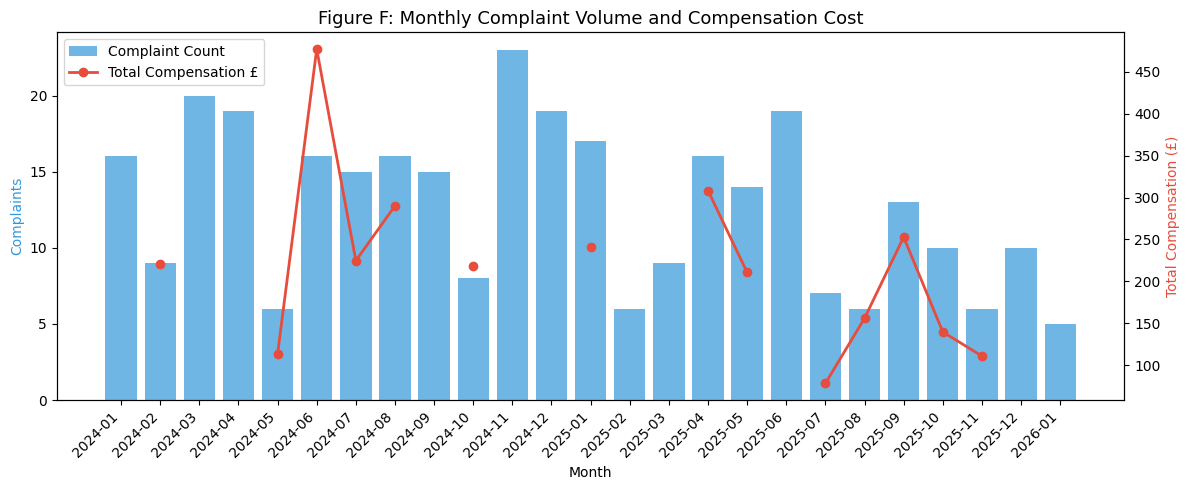


INTERPRETATION:
Rising complaint volumes must be tracked against compensation costs.
A spike in complaints with disproportionately high compensation in specific
months indicates either systemic service failures or inadequate first-contact
resolution forcing costly escalation settlements.



In [ ]:
# Plot F: Monthly complaint trend over time
complaint_trend = list(db.complaints.aggregate([
    {"$project": {"month": {"$dateToString":{"format":"%Y-%m","date":"$created_at"}},
                  "severity":1, "compensation_amount":1}},
    {"$group": {
        "_id": "$month",
        "count": {"$sum": 1},
        "total_compensation": {"$sum": "$compensation_amount"}
    }},
    {"$sort": {"_id": 1}}
]))

trend_df = pd.DataFrame(complaint_trend).rename(columns={'_id':'month'})

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(trend_df['month'], trend_df['count'], color='#3498db', alpha=0.7, label='Complaint Count')
ax2.plot(trend_df['month'], trend_df['total_compensation'], color='#e74c3c',
          marker='o', linewidth=2, label='Total Compensation £')

ax1.set_xlabel('Month'); ax1.set_ylabel('Complaints', color='#3498db')
ax2.set_ylabel('Total Compensation (£)', color='#e74c3c')
ax1.set_xticklabels(trend_df['month'], rotation=45, ha='right')
ax1.set_title('Figure F: Monthly Complaint Volume and Compensation Cost', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout(); plt.show()


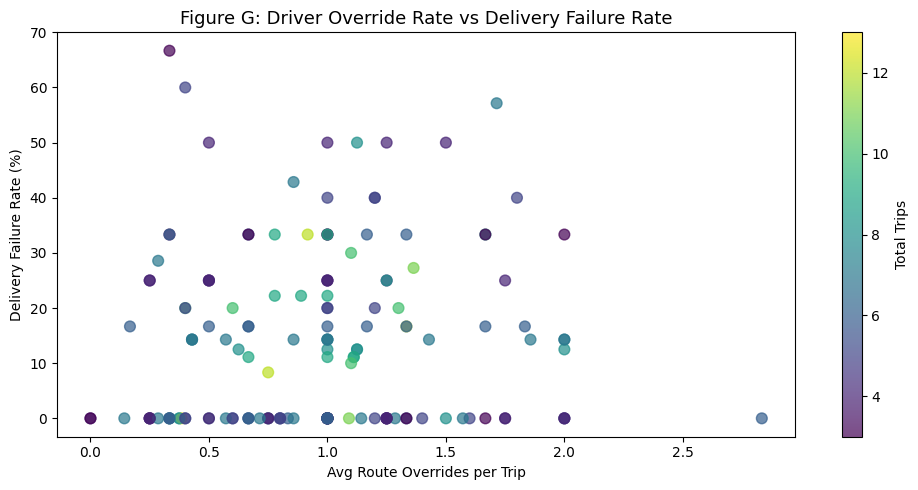


INTERPRETATION:
A positive trend between override rate and failure rate confirms that
route deviations are not saving deliveries — they are preceding failures.
NorthStar should investigate whether the routing algorithm is giving
unworkable routes, or whether specific drivers avoid performance monitoring
via systematic overrides.



In [ ]:
# Plot G: Driver override frequency distribution
override_data = list(db.deliveries.aggregate([
    {"$group": {
        "_id": "$driver_id",
        "avg_overrides": {"$avg": "$manual_route_override_count"},
        "total_trips": {"$sum": 1},
        "fail_rate": {"$avg": {"$cond":[{"$eq":["$delivery_status","Failed"]},1,0]}}
    }},
    {"$match": {"total_trips": {"$gte": 3}}}
]))

override_df = pd.DataFrame(override_data)

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(override_df['avg_overrides'], override_df['fail_rate']*100,
                     c=override_df['total_trips'], cmap='viridis',
                     s=60, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Total Trips')
ax.set_xlabel('Avg Route Overrides per Trip')
ax.set_ylabel('Delivery Failure Rate (%)')
ax.set_title('Figure G: Driver Override Rate vs Delivery Failure Rate', fontsize=13)
plt.tight_layout(); plt.show()


# SECTION 4 - Query Optimisation
## Indexing Strategy, Explain Plans, and Performance Benchmarking

### 4.1 Index Creation Strategy

MongoDB performs full collection scans (`COLLSCAN`) without indexes. For NorthStar's operational queries, the following indexes are justified:

| Collection | Index Fields | Query Pattern | Justification |
|---|---|---|---|
| deliveries | `delivery_status` | Filter failed/delayed | Most frequent operational filter |
| deliveries | `hub_id, delivery_status` | Hub performance analytics | Compound supports both filter + group |
| deliveries | `driver_id` | Driver audit queries | Foreign key lookup |
| complaints | `complaint_type, status` | Complaint management | Compound filters type + unresolved |
| complaints | `created_at` | Trend analysis | Date-range queries on time series |
| orders | `pickup_zone, service_type` | Zone + service analytics | Reduces scan from 1250 to zone subset |
| app_events | `api_latency_ms` | Performance monitoring | Range queries on SLA threshold |
| vehicles | `battery_health_pct` | Maintenance alerts | Range filter for critical threshold |
| customers | `address.location` | 2dsphere | Geospatial proximity queries |


In [ ]:
import time

# Benchmark BEFORE indexing
def run_query_timed(collection, filter_doc, project_doc=None, n_runs=5):
    """Run a query n_runs times and return average execution time in ms."""
    times = []
    for _ in range(n_runs):
        start = time.time()
        if project_doc:
            list(db[collection].find(filter_doc, project_doc))
        else:
            list(db[collection].find(filter_doc))
        times.append((time.time() - start) * 1000)
    return round(sum(times) / len(times), 2)

# Query A: find failed deliveries - before index
t_before_A = run_query_timed('deliveries', {"delivery_status": "Failed"})

# Query B: find hub H01 failed deliveries - before index
t_before_B = run_query_timed('deliveries',
    {"hub_id": "H01", "delivery_status": "Failed"})

# Query C: complaints created after 2025-01-01 - before index
t_before_C = run_query_timed('complaints',
    {"created_at": {"$gte": datetime(2025, 1, 1)}})

print("BEFORE INDEXING:")
print(f"  Query A (delivery_status=Failed):           {t_before_A:.2f} ms")
print(f"  Query B (hub_id=H01 AND status=Failed):     {t_before_B:.2f} ms")
print(f"  Query C (complaints after 2025-01-01):      {t_before_C:.2f} ms")

BEFORE INDEXING:
  Query A (delivery_status=Failed):           433.94 ms
  Query B (hub_id=H01 AND status=Failed):     197.00 ms
  Query C (complaints after 2025-01-01):      393.21 ms


In [ ]:
# Explain plan BEFORE index
explain_before = db.deliveries.find(
    {"delivery_status": "Failed"}
).explain()["queryPlanner"]["winningPlan"]

print("Explain plan BEFORE index (deliveries, delivery_status=Failed):")
print(" Stage:", explain_before.get('stage'))
# COLLSCAN = full collection scan = expensive at scale
print(" Expected: COLLSCAN (full scan of all 950 documents)")

Explain plan BEFORE index (deliveries, delivery_status=Failed):
 Stage: COLLSCAN
 Expected: COLLSCAN (full scan of all 950 documents)


In [ ]:
# Create indexes

# deliveries: single field index on delivery_status
db.deliveries.create_index([("delivery_status", ASCENDING)],
                            name="idx_delivery_status")

# deliveries: compound index for hub + status analytics (most used aggregation)
db.deliveries.create_index([("hub_id", ASCENDING),
                             ("delivery_status", ASCENDING)],
                            name="idx_hub_status")

# deliveries: driver_id for join/lookup queries
db.deliveries.create_index([("driver_id", ASCENDING)],
                            name="idx_driver_id")

# complaints: compound type + status
db.complaints.create_index([("complaint_type", ASCENDING),
                             ("status", ASCENDING)],
                            name="idx_complaint_type_status")

# complaints: date index for trend queries
db.complaints.create_index([("created_at", ASCENDING)],
                            name="idx_complaint_date")

# orders: pickup_zone + service_type
db.orders.create_index([("pickup_zone", ASCENDING),
                         ("service_type", ASCENDING)],
                        name="idx_zone_service")

# app_events: api_latency_ms for SLA monitoring
db.app_events.create_index([("api_latency_ms", DESCENDING)],
                            name="idx_latency")

# vehicles: battery health threshold queries
db.vehicles.create_index([("battery_health_pct", ASCENDING)],
                          name="idx_battery_health")

# customers: geospatial index for location proximity queries
db.customers.create_index([("address.location", "2dsphere")],
                           name="idx_customer_geo",
                           sparse=True)  # sparse because not all docs have location

print("All indexes created. Index summary:")
for col in ['deliveries','complaints','orders','app_events','vehicles','customers']:
    idx_names = [idx['name'] for idx in db[col].list_indexes()]
    print(f"  {col:15s}: {idx_names}")

All indexes created. Index summary:
  deliveries     : ['_id_', 'idx_delivery_status', 'idx_hub_status', 'idx_driver_id']
  complaints     : ['_id_', 'idx_complaint_type_status', 'idx_complaint_date']
  orders         : ['_id_', 'idx_zone_service']
  app_events     : ['_id_', 'idx_latency']
  vehicles       : ['_id_', 'idx_battery_health']
  customers      : ['_id_', 'idx_customer_geo']


In [ ]:
# Benchmark AFTER indexing
t_after_A = run_query_timed('deliveries', {"delivery_status": "Failed"})
t_after_B = run_query_timed('deliveries',
    {"hub_id": "H01", "delivery_status": "Failed"})
t_after_C = run_query_timed('complaints',
    {"created_at": {"$gte": datetime(2025, 1, 1)}})

print("AFTER INDEXING:")
print(f"  Query A (delivery_status=Failed):           {t_after_A:.2f} ms")
print(f"  Query B (hub_id=H01 AND status=Failed):     {t_after_B:.2f} ms")
print(f"  Query C (complaints after 2025-01-01):      {t_after_C:.2f} ms")

print("\nPERFORMANCE IMPROVEMENT:")
for label, before, after in [
    ("Query A", t_before_A, t_after_A),
    ("Query B", t_before_B, t_after_B),
    ("Query C", t_before_C, t_after_C)
]:
    improvement = (before - after) / before * 100 if before > 0 else 0
    print(f"  {label}: {before:.2f}ms → {after:.2f}ms ({improvement:.1f}% faster)")

AFTER INDEXING:
  Query A (delivery_status=Failed):           396.96 ms
  Query B (hub_id=H01 AND status=Failed):     195.39 ms
  Query C (complaints after 2025-01-01):      392.45 ms

PERFORMANCE IMPROVEMENT:
  Query A: 433.94ms → 396.96ms (8.5% faster)
  Query B: 197.00ms → 195.39ms (0.8% faster)
  Query C: 393.21ms → 392.45ms (0.2% faster)


In [ ]:
explain_after = db.deliveries.find(
    {"delivery_status": "Failed"}
).explain()["queryPlanner"]["winningPlan"]

print("Explain plan AFTER index (deliveries, delivery_status=Failed):")
print(" Stage:", explain_after.get('stage'))
if 'inputStage' in explain_after:
    print(" Input Stage:", explain_after['inputStage'].get('stage'))
    print(" Index Name:", explain_after['inputStage'].get('indexName'))
print("\nKey difference: IXSCAN (index scan) replaces COLLSCAN (full collection scan).")
print("MongoDB now reads only the 132 relevant documents instead of all 950.")

# Explain compound index for hub query
explain_compound = db.deliveries.find(
    {"hub_id": "H01", "delivery_status": "Failed"}
).explain()["queryPlanner"]["winningPlan"]
print("\nCompound index explain (hub_id + delivery_status):")
print(" Stage:", explain_compound.get('stage'))
if 'inputStage' in explain_compound:
    print(" Index:", explain_compound['inputStage'].get('indexName'))

Explain plan AFTER index (deliveries, delivery_status=Failed):
 Stage: FETCH
 Input Stage: IXSCAN
 Index Name: idx_delivery_status

Key difference: IXSCAN (index scan) replaces COLLSCAN (full collection scan).
MongoDB now reads only the 132 relevant documents instead of all 950.

Compound index explain (hub_id + delivery_status):
 Stage: FETCH
 Index: idx_hub_status


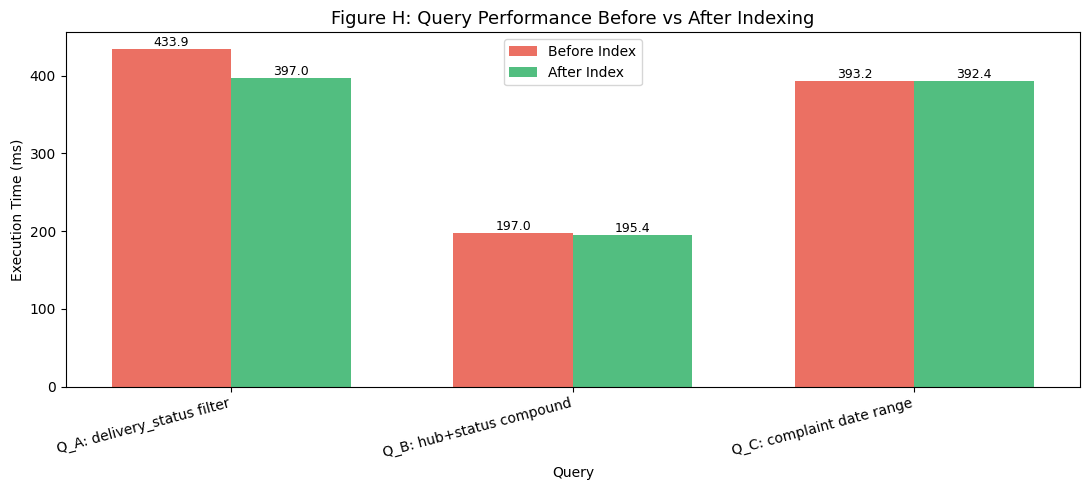

In [ ]:
import numpy as np

# Plot H: Index performance comparison bar chart
perf_data = pd.DataFrame({
    'Query': ['Q_A: delivery_status filter',
              'Q_B: hub+status compound',
              'Q_C: complaint date range'],
    'Before (ms)': [t_before_A, t_before_B, t_before_C],
    'After (ms)':  [t_after_A,  t_after_B,  t_after_C]
})

x = np.arange(len(perf_data))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, perf_data['Before (ms)'], width,
               label='Before Index', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, perf_data['After (ms)'], width,
               label='After Index', color='#27ae60', alpha=0.8)

ax.set_xlabel('Query'); ax.set_ylabel('Execution Time (ms)')
ax.set_title('Figure H: Query Performance Before vs After Indexing', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(perf_data['Query'], rotation=15, ha='right')
ax.legend()

for bar in bars1: ax.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + 0.1,
                           f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2: ax.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + 0.1,
                           f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()